Dataset Overview

This dataset contains monthly transportation statistics including highway fatalities, rail incidents, air safety metrics, and transportation service indices. The goal is to explore patterns in transportation safety and activity and identify natural groupings within the data.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Monthly_Transportation_Statistics_20260308.csv")

df.head()

,Index,Date,Air Safety - General Aviation Fatalities,Highway Fatalities Per 100 Million Vehicle Miles Traveled,Highway Fatalities,U.S. Airline Traffic - Total - Seasonally Adjusted,U.S. Airline Traffic - International - Seasonally Adjusted,U.S. Airline Traffic - Domestic - Seasonally Adjusted,Transit Ridership - Other Transit Modes - Adjusted,Transit Ridership - Fixed Route Bus - Adjusted,...,Heavy truck sales SAAR (millions),U.S. Airline Traffic - Total - Non Seasonally Adjusted,Light truck sales SAAR (millions),U.S. Airline Traffic - International - Non Seasonally Adjusted,Auto sales SAAR (millions),U.S. Airline Traffic - Domestic - Non Seasonally Adjusted,Transborder - Total North American Freight,Transborder - U.S. - Mexico Freight,U.S. marketing air carriers on-time performance (percent),Transborder - U.S. - Canada Freight
0,0,1947 Jan 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1947 Feb 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1947 Mar 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1947 Apr 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1947 May 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Columns: 136 entries, Index to Transborder - U.S. - Canada Freight
dtypes: float64(13), int64(1), str(122)
memory usage: 1010.6 KB


,Index,Air Safety - General Aviation Fatalities,Highway Fatalities Per 100 Million Vehicle Miles Traveled,National Highway Construction Cost Index (NHCCI),Passenger Rail Total Reports,Rail Fatalities,Rail Fatalities at Highway-Rail Crossings,Trespasser Fatalities Not at Highwaya-Rail Crossings,Transportation Services Index - Freight,Transportation Services Index - Passenger,Transportation Services Index - Combined,Air Safety - Air Taxi and Commuter Fatalities,Air Safety - Air Carrier Fatalities,Truck tonnage index
count,951.000000,536.000000,51.000000,90.000000,0.0,611.000000,611.000000,611.000000,312.000000,312.000000,312.000000,287.000000,315.000000,313.000000
mean,475.000000,60.531716,1.195882,1.806372,NaN,86.193126,40.418985,40.237316,118.587500,110.206731,114.914744,2.233449,1.387302,95.515974
std,274.674353,44.959368,0.119418,0.572580,NaN,24.889632,21.775710,11.357715,13.758241,19.059490,11.813499,3.386191,10.883978,14.889813
min,0.000000,1.000000,0.990000,1.000000,NaN,40.000000,8.000000,15.000000,94.900000,13.000000,81.000000,0.000000,0.000000,72.500000
25%,237.500000,32.000000,1.110000,1.504017,NaN,68.000000,24.000000,32.000000,108.575000,102.475000,106.875000,0.000000,0.000000,82.900000
50%,475.000000,50.000000,1.180000,1.644421,NaN,83.000000,34.000000,39.000000,114.400000,114.000000,112.600000,1.000000,0.000000,92.000000
75%,712.500000,77.000000,1.275000,1.905797,NaN,101.000000,54.000000,48.000000,134.425000,122.825000,123.700000,3.000000,0.000000,112.500000
max,950.000000,345.000000,1.440000,3.362867,NaN,178.000000,131.000000,72.000000,140.600000,137.000000,138.800000,22.000000,160.000000,120.400000


The dataset contains 951 observations and multiple transportation-related metrics. Most variables are numeric indicators related to fatalities, transportation indices, and traffic measurements.

## Exploratory Data Analysis

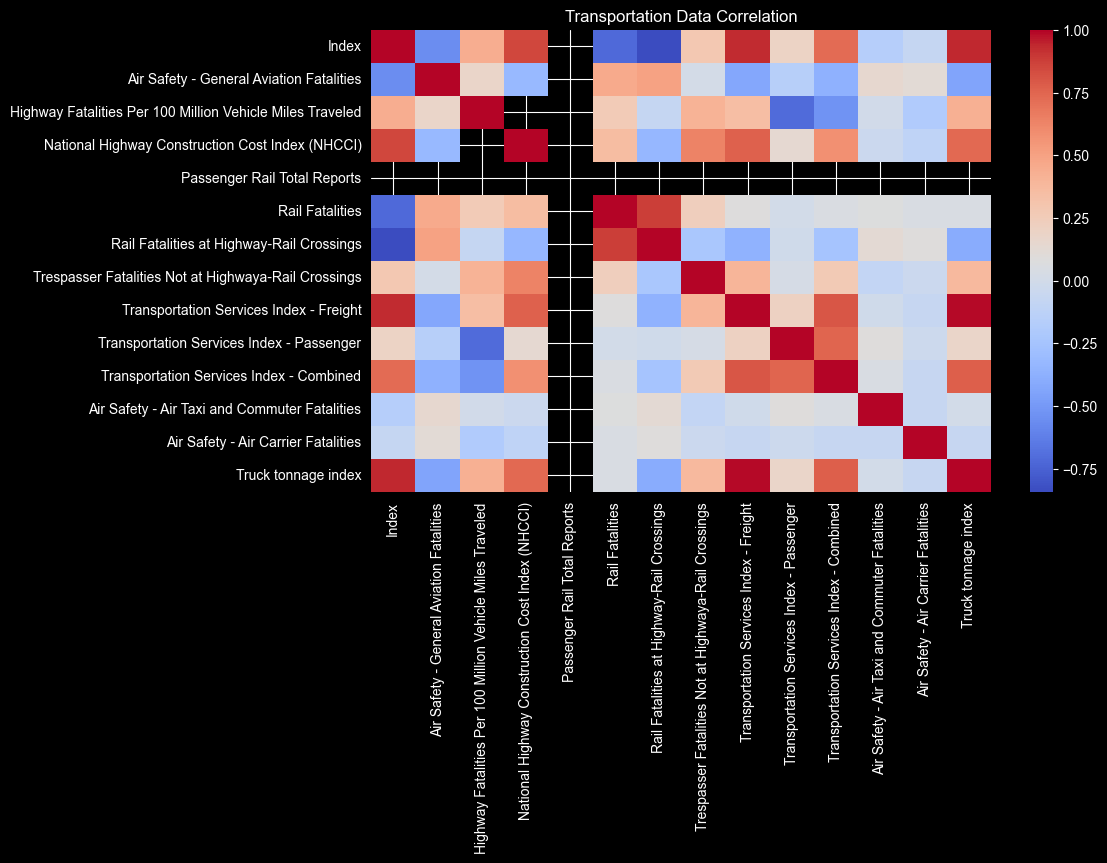

In [57]:
plt.figure(figsize=(10, 6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Transportation Data Correlation")

plt.show()

Several transportation fatality metrics show moderate correlation, particularly between rail fatalities and highway-rail crossing fatalities.

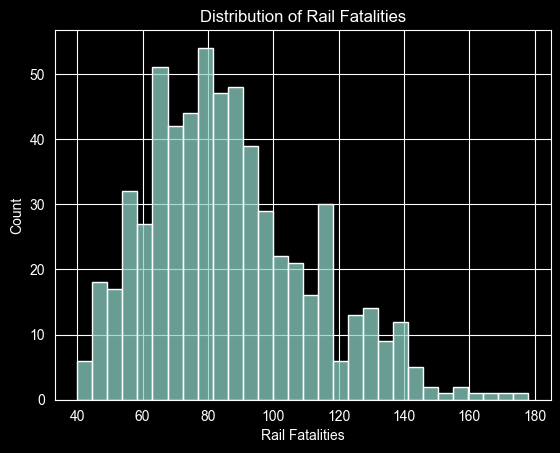

In [69]:
sns.histplot(df["Rail Fatalities"], bins=30)
plt.title("Distribution of Rail Fatalities")
plt.show()

Rail fatalities are skewed toward lower values with occasional spikes.

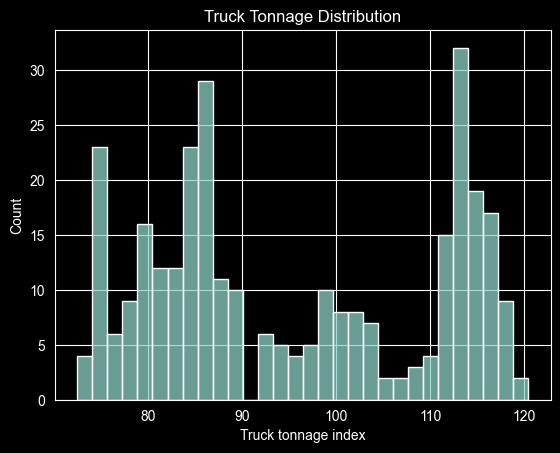

In [71]:
sns.histplot(df["Truck tonnage index"], bins=30)
plt.title("Truck Tonnage Distribution")
plt.show()

The truck tonnage index shows relatively stable variation, indicating consistent freight activity.

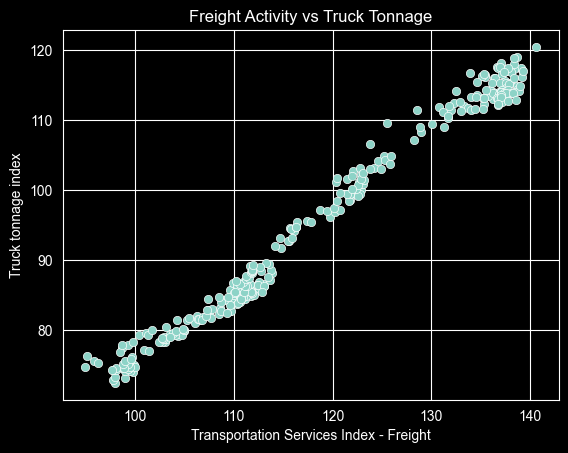

In [72]:
sns.scatterplot(
    x=df["Transportation Services Index - Freight"],
    y=df["Truck tonnage index"]
)
plt.title("Freight Activity vs Truck Tonnage")
plt.show()

Freight index and truck tonnage appear positively related, suggesting higher freight movement corresponds with increased trucking activity.

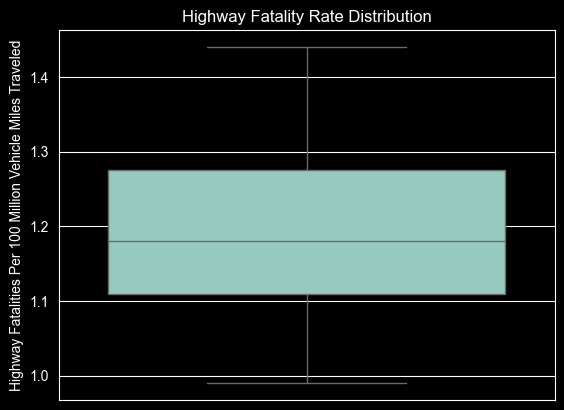

In [73]:
sns.boxplot(y=df["Highway Fatalities Per 100 Million Vehicle Miles Traveled"])
plt.title("Highway Fatality Rate Distribution")
plt.show()

Some outliers appear in highway fatality rates, likely corresponding to unusually dangerous months.

Several preprocessing steps were required before mining:

Removed non-numeric columns for clustering

Replaced infinite values with NaN

Removed columns containing only missing values

Imputed remaining missing values using the column mean

Standardized all numeric features using Z-score normalization to ensure equal weighting in distance calculations

In [75]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.fillna(numeric_df.mean())

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_data = pd.DataFrame(scaled_data, columns=numeric_df.columns)

Clustering was selected because the discovery question focuses on identifying natural groupings in transportation patterns. K-Means clustering was chosen because it is widely used for numeric datasets and works well with standardized features.

### Elbow Method Interpretation

The elbow plot suggests that **k = 3 clusters** provides a good balance between model complexity and variance explained. After this point, adding more clusters produces only small reductions in inertia.

In [80]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [81]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

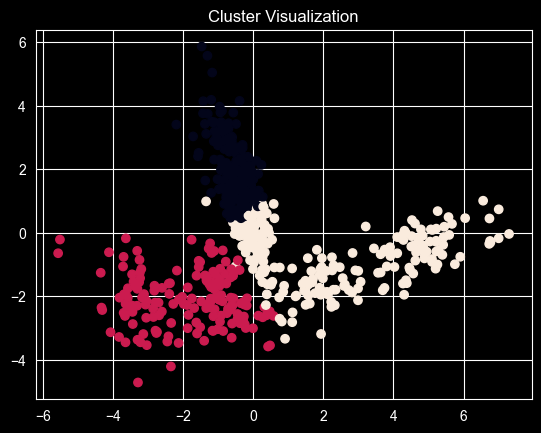

In [82]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2"])
pca_df["Cluster"] = clusters

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Cluster"])
plt.title("Cluster Visualization")
plt.show()

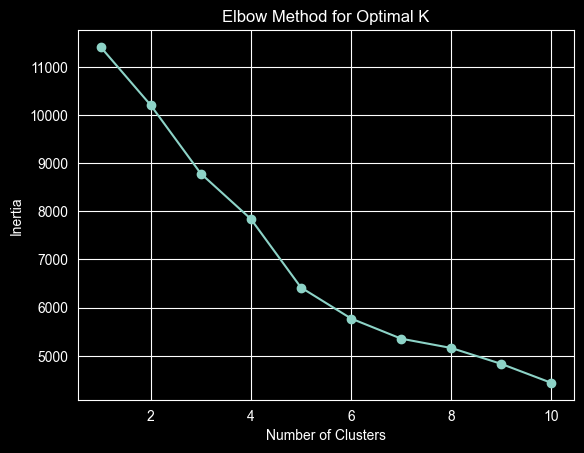

In [61]:
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [83]:
numeric_df["Cluster"] = clusters

numeric_df.groupby("Cluster").mean()

,Index,Air Safety - General Aviation Fatalities,Highway Fatalities Per 100 Million Vehicle Miles Traveled,National Highway Construction Cost Index (NHCCI),Rail Fatalities,Rail Fatalities at Highway-Rail Crossings,Trespasser Fatalities Not at Highwaya-Rail Crossings,Transportation Services Index - Freight,Transportation Services Index - Passenger,Transportation Services Index - Combined,Air Safety - Air Taxi and Commuter Fatalities,Air Safety - Air Carrier Fatalities,Truck tonnage index
Cluster,,,,,,,,,,,,,
0,451.545918,87.979297,1.195882,1.806372,114.005102,66.045918,38.683673,118.587500,110.206731,114.914744,2.498062,1.314367,95.515974
1,725.388235,50.588235,1.198356,1.715446,68.458824,26.376471,38.688235,108.175882,102.838235,106.120000,2.076901,1.227003,84.020000
2,410.095726,54.225163,1.195163,1.832795,82.028484,35.913598,41.208013,121.613098,112.348003,117.470481,2.190286,1.458320,98.856685


### Cluster Interpretation

The K-Means clustering algorithm identified three distinct transportation patterns in the dataset. By examining the average feature values within each cluster, we can understand how transportation activity and safety metrics differ across these groups.

**Cluster 0 – Moderate Freight and Safety Activity**

Cluster 0 represents observations with moderate levels of transportation activity. Freight-related indicators such as the Transportation Services Index and Truck Tonnage Index fall in the mid-range compared to the other clusters. Fatality metrics such as highway and rail fatalities are also relatively moderate. This cluster likely represents typical operational periods where transportation systems function under normal conditions without unusually high freight demand or extreme safety incidents.

**Cluster 1 – High Fatality / Lower Activity Periods**

Cluster 1 shows significantly higher values for fatality-related variables, particularly Air Safety – General Aviation Fatalities and Rail Fatalities. At the same time, freight and passenger transportation indices are lower compared to the other clusters. This cluster likely represents periods with higher transportation safety risks but relatively lower overall transportation activity. These observations may correspond to months with unusual safety incidents or environmental factors affecting transportation safety.

**Cluster 2 – High Transportation Activity Periods**

Cluster 2 shows the highest values for transportation service indices and truck tonnage indicators. Freight and passenger transportation activity appear to be strongest in this cluster, suggesting periods of increased economic or logistical activity. Fatality metrics are present but not as elevated as in Cluster 1, indicating that high activity does not necessarily correspond to the highest fatality levels.

Overall, the clustering results suggest that transportation patterns can be categorized into three main operational regimes: moderate activity periods, higher safety-risk periods, and high transportation demand periods. These findings indicate that transportation systems experience varying patterns of activity and safety over time, which may be influenced by economic conditions, seasonal factors, or infrastructure demands.